In [1]:
import pathlib
from os import path, getcwd

import numpy as np
from tqdm import tqdm


def read_data(parent_dir: pathlib.Path) -> (list, list):
    folders = [item for item in parent_dir.iterdir() if item.is_dir()]
    folders.sort()
    sep_dists = list()
    failure_prob = list()
    for folder in tqdm(folders):
        separation_distance = float(folder.name.split('-')[1])
        fp_output = folder / f'{folder.name}_out.csv'
        try:
            assert path.exists(fp_output), f'file does not exist {fp_output}'
        except AssertionError:
            continue
        mcs_output = np.genfromtxt(fp_output, delimiter=",", skip_header=1)

        N = np.shape(mcs_output)[0]

        # find all iterations that ignition occurred
        t_ig_ftp = mcs_output[:, 2]
        P_ig = sum(np.logical_and(t_ig_ftp > 0, t_ig_ftp < np.inf)) / N

        sep_dists.append(separation_distance)
        failure_prob.append(P_ig)
    return sep_dists, failure_prob


data = dict(
    br187_normal=read_data(pathlib.Path(getcwd(), 'br187_normal')),
    br187_sprinkler=read_data(pathlib.Path(getcwd(), 'br187_sprinkler')),
    cfast_sprinkler=read_data(pathlib.Path(getcwd(), 'cfast_sprinkler')),
)

100%|██████████| 9/9 [00:00<?, ?it/s]


Text(2.1, 0.12758658131122586, '0.13759')

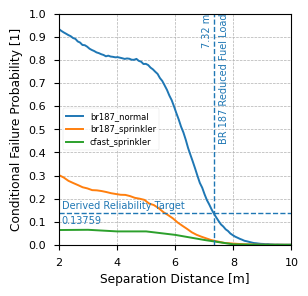

In [26]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-paper')

fig, ax = plt.subplots(figsize=(3, 3), dpi=100)

ax.set_xlabel("Separation Distance [m]")
ax.set_ylabel("Conditional Failure Probability [1]")
ax.set_xlim(2, 10)
ax.set_ylim(0, 1)
ax.set_yticks(np.arange(0, 1.1, 0.1))
ax.grid(which="both", ls="--", lw=0.5)

# br 187 084 base case
lines = dict()
for label, data_ in data.items():
    lines[label] = ax.plot(*data_, label=label)

ax.legend(loc='center left', fontsize=6).set_visible(True)

# target
x_ = 7.320449646472931
y_ = np.interp(x_, *data['br187_normal'])
line_color = lines['br187_normal'][0].get_color()
ax.axvline(x_, ls="--", color=line_color, lw=1)
ax.text(x_ + 0.2, 1, "BR 187 Reduced Fuel Load", color=line_color, ha="left", va="top", rotation=90, fontsize=7)
ax.text(x_ - 0.05, 1, f"{x_:.2f} m", color=line_color, ha="right", va="top", rotation=90, fontsize=7)
ax.axhline(y_, ls="--", color=line_color, lw=1)
ax.text(2.1, y_ + 0.01, "Derived Reliability Target", color=line_color, ha="left", va="bottom", fontsize=7)
ax.text(2.1, y_ - 0.01, f"{y_:.5f}", color=line_color, ha="left", va="top", fontsize=7)

fig.tight_layout()
fig.show()